# 04 — PlantVillage Mask-Guided Counterfactual Consistency Distillation

## Proposed Classification Experiment

**Backbone:** EfficientNet-B0 + ImageNet pretraining  
**Final inference input:** ordinary RGB image only  
**Classes:** 38  
**Training samples:** 43,443  
**Validation samples:** 5,430  
**Test samples:** 5,431

This experiment combines four ideas:

1. **Ordinary supervised classification** on the original RGB image.
2. **Counterfactual supervised classification** after changing only the background.
3. **Leaf-focused knowledge distillation** from the completed leaf-only teacher.
4. **Original-vs-counterfactual consistency regularization** so predictions remain stable when background changes.

The teacher is used only during training through its precomputed logits.  
At inference time, the student requires **only RGB input**.

## Loss

\[
\mathcal{L} =
\mathcal{L}_{CE}^{RGB}
+ \alpha\,\mathcal{L}_{CE}^{CF}
+ \beta\,\mathcal{L}_{KD}
+ \gamma\,\mathcal{L}_{JS}
\]

with:

```text
alpha = 0.75
beta  = 0.25
gamma = 0.25
KD temperature = 3.0
```

These are deliberately moderate regularization weights because the standard RGB baseline is already extremely strong in-domain, while its counterfactual robustness is substantially weaker.

## Model Selection

The best checkpoint is selected using the **harmonic mean of validation Macro F1 on:**

- Original RGB
- Counterfactual background

This prevents the model from being selected solely for ordinary PlantVillage accuracy while ignoring robustness.

## Runtime protection

The notebook saves:

```text
best_model.pth
last_checkpoint.pth
```

after completed epochs. If Colab disconnects, reopen the notebook and use **Run all**.

## Cross-Gmail use

The Drive must contain:

```text
MyDrive/PlantVillage_Classification/
├── final_classification_manifest_v2.csv
├── classification_class_map_v2.json
├── classification_unet_masks_packed.npz
└── experiments/
    └── Leaf_Only_Teacher_EfficientNetB0/
        └── results/
            └── teacher_logits.npz
```

Alternatively, `teacher_logits.npz` may be copied directly to:

```text
MyDrive/PlantVillage_Classification/teacher_logits.npz
```


# STEP 1 — Install and Import

In [1]:
!pip -q install kagglehub scikit-learn

import gc
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import kagglehub
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Enable a T4 GPU before running this notebook."
    )

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print("Seed:", SEED)


Device: cuda
GPU: Tesla T4
Seed: 42


# STEP 2 — Download PlantVillage and Detect Dataset Root

In [2]:
download_path = Path(
    kagglehub.dataset_download(
        "abdallahalidev/plantvillage-dataset"
    )
)

def find_dataset_root(base):

    required = {
        "color",
        "grayscale",
        "segmented"
    }

    candidates = [base] + [
        p
        for p in base.rglob("*")
        if p.is_dir()
    ]

    for path in candidates:

        try:

            names = {
                p.name
                for p in path.iterdir()
                if p.is_dir()
            }

            if required.issubset(
                names
            ):
                return path

        except PermissionError:
            pass

    return None


dataset_root = find_dataset_root(
    download_path
)

assert dataset_root is not None

print(
    "Dataset root:",
    dataset_root
)


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset root: /kaggle/input/plantvillage-dataset/plantvillage dataset


# STEP 3 — Mount Drive and Verify Final Artifacts

In [3]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "PlantVillage_Classification"
)

MANIFEST_PATH = (
    PROJECT_DIR /
    "final_classification_manifest_v2.csv"
)

CLASS_MAP_PATH = (
    PROJECT_DIR /
    "classification_class_map_v2.json"
)

MASK_ARCHIVE = (
    PROJECT_DIR /
    "classification_unet_masks_packed.npz"
)

TEACHER_LOGIT_CANDIDATES = [
    (
        PROJECT_DIR /
        "experiments" /
        "Leaf_Only_Teacher_EfficientNetB0" /
        "results" /
        "teacher_logits.npz"
    ),
    (
        PROJECT_DIR /
        "teacher_logits.npz"
    )
]

TEACHER_LOGITS_PATH = None

for candidate in TEACHER_LOGIT_CANDIDATES:

    if candidate.exists():

        TEACHER_LOGITS_PATH = candidate
        break


for path in [
    MANIFEST_PATH,
    CLASS_MAP_PATH,
    MASK_ARCHIVE
]:

    print(
        "✅" if path.exists() else "❌",
        path
    )

    assert path.exists()


assert TEACHER_LOGITS_PATH is not None, (
    "teacher_logits.npz was not found. "
    "Copy it from the completed Leaf-Only Teacher experiment."
)

print(
    "✅ Teacher logits:",
    TEACHER_LOGITS_PATH
)


df = pd.read_csv(
    MANIFEST_PATH
)


with open(
    CLASS_MAP_PATH,
    "r"
) as f:

    class_map = json.load(f)


CLASS_NAMES = [
    class_map[
        "id_to_class"
    ][
        str(i)
    ]

    for i in range(
        38
    )
]


assert len(df) == 54304
assert (df["split"] == "train").sum() == 43443
assert (df["split"] == "val").sum() == 5430
assert (df["split"] == "test").sum() == 5431
assert df["class"].nunique() == 38


EXPERIMENT_DIR = (
    PROJECT_DIR /
    "experiments" /
    "MG_CCD_EfficientNetB0"
)

CHECKPOINT_DIR = (
    EXPERIMENT_DIR /
    "checkpoints"
)

RESULTS_DIR = (
    EXPERIMENT_DIR /
    "results"
)

VISUAL_DIR = (
    EXPERIMENT_DIR /
    "visuals"
)

for folder in [
    EXPERIMENT_DIR,
    CHECKPOINT_DIR,
    RESULTS_DIR,
    VISUAL_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print(
    "Experiment:",
    EXPERIMENT_DIR
)


Mounted at /content/drive
✅ /content/drive/MyDrive/PlantVillage_Classification/final_classification_manifest_v2.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/classification_class_map_v2.json
✅ /content/drive/MyDrive/PlantVillage_Classification/classification_unet_masks_packed.npz
✅ Teacher logits: /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/results/teacher_logits.npz
Experiment: /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0


# STEP 4 — Load U-Net Masks and Teacher Logits

In [4]:
with np.load(
    MASK_ARCHIVE
) as data:

    MASK_IDS = (
        data[
            "sample_ids"
        ]
        .astype(str)
    )

    PACKED_MASKS = (
        data[
            "packed_masks"
        ]
    )


MASK_INDEX = {
    sample_id:
        i

    for i, sample_id
    in enumerate(
        MASK_IDS
    )
}


with np.load(
    TEACHER_LOGITS_PATH
) as data:

    TEACHER_IDS = (
        data[
            "sample_ids"
        ]
        .astype(str)
    )

    TEACHER_LOGITS = (
        data[
            "logits"
        ]
        .astype(
            np.float32
        )
    )


TEACHER_INDEX = {
    sample_id:
        i

    for i, sample_id
    in enumerate(
        TEACHER_IDS
    )
}


assert len(
    MASK_INDEX
) == 54304

assert TEACHER_LOGITS.shape == (
    54304,
    38
)


missing_teacher = [
    sample_id
    for sample_id in df[
        "sample_id"
    ].astype(str)
    if sample_id
    not in TEACHER_INDEX
]


assert len(
    missing_teacher
) == 0


def get_mask(
    sample_id
):

    packed = PACKED_MASKS[
        MASK_INDEX[
            str(
                sample_id
            )
        ]
    ]

    return np.unpackbits(
        packed
    )[
        :
        256 * 256
    ].reshape(
        256,
        256
    ).astype(
        np.uint8
    )


def get_teacher_logits(
    sample_id
):

    return TEACHER_LOGITS[
        TEACHER_INDEX[
            str(
                sample_id
            )
        ]
    ]


print(
    "Masks:",
    len(
        MASK_INDEX
    )
)

print(
    "Teacher logits:",
    TEACHER_LOGITS.shape
)

print(
    "✅ Mask and teacher knowledge stores verified."
)


Masks: 54304
Teacher logits: (54304, 38)
✅ Mask and teacher knowledge stores verified.


# STEP 5 — Define Leaf / Background / Counterfactual Views

In [5]:
NEUTRAL_RGB = np.array(
    [
        124,
        116,
        104
    ],
    dtype=np.uint8
)


def resize_mask(
    mask,
    image
):

    if mask.shape != image.shape[:2]:

        mask = cv2.resize(
            mask,
            (
                image.shape[
                    1
                ],
                image.shape[
                    0
                ]
            ),
            interpolation=
                cv2.INTER_NEAREST
        )

    return mask


def make_leaf_only(
    image,
    mask
):

    mask = resize_mask(
        mask,
        image
    )

    output = np.empty_like(
        image
    )

    output[:] = NEUTRAL_RGB

    output[
        mask == 1
    ] = image[
        mask == 1
    ]

    return output


def make_background_only(
    image,
    mask
):

    mask = resize_mask(
        mask,
        image
    )

    output = image.copy()

    output[
        mask == 1
    ] = NEUTRAL_RGB

    return output


def make_clean_donor_background(
    donor_image,
    donor_mask
):

    donor_mask = resize_mask(
        donor_mask,
        donor_image
    )

    output = donor_image.copy()

    background_pixels = output[
        donor_mask == 0
    ]

    fill_rgb = (
        np.median(
            background_pixels,
            axis=0
        )
        .astype(
            np.uint8
        )

        if len(
            background_pixels
        ) > 0

        else NEUTRAL_RGB
    )


    output[
        donor_mask == 1
    ] = fill_rgb


    output = cv2.GaussianBlur(
        output,
        (
            15,
            15
        ),
        0
    )


    return output


def make_counterfactual(
    target_image,
    target_mask,
    donor_image,
    donor_mask
):

    target_mask = resize_mask(
        target_mask,
        target_image
    )


    donor_background = (
        make_clean_donor_background(
            donor_image,
            donor_mask
        )
    )


    if donor_background.shape[:2] != target_image.shape[:2]:

        donor_background = cv2.resize(
            donor_background,
            (
                target_image.shape[
                    1
                ],
                target_image.shape[
                    0
                ]
            ),
            interpolation=
                cv2.INTER_LINEAR
        )


    output = donor_background.copy()

    output[
        target_mask == 1
    ] = target_image[
        target_mask == 1
    ]


    return output


# STEP 6 — Define Training and Evaluation Transformations

In [6]:
IMAGE_SIZE = 224


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(
            0.80,
            1.00
        )
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


eval_transform = transforms.Compose([
    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


def synchronized_train_transform(
    image_a,
    image_b
):

    # Reuse exactly the same stochastic torchvision
    # augmentation parameters for both views.
    torch_state = (
        torch.get_rng_state()
    )

    python_state = (
        random.getstate()
    )

    numpy_state = (
        np.random.get_state()
    )


    tensor_a = train_transform(
        image_a
    )


    torch.set_rng_state(
        torch_state
    )

    random.setstate(
        python_state
    )

    np.random.set_state(
        numpy_state
    )


    tensor_b = train_transform(
        image_b
    )


    return (
        tensor_a,
        tensor_b
    )


## Why synchronized augmentation?

The consistency loss is intended to measure sensitivity to **background intervention**, not sensitivity to different random crops.

Therefore, the original and counterfactual versions of the same leaf receive the same random crop, flips, and color jitter during training.


# STEP 7 — Create Proposed Training Dataset

In [7]:
row_lookup = (
    df
    .set_index(
        "sample_id"
    )
)


class ProposedTrainingDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]


        sample_id = str(
            row[
                "sample_id"
            ]
        )


        image = np.array(
            Image.open(
                dataset_root /
                row[
                    "color_rel"
                ]
            ).convert(
                "RGB"
            )
        )


        mask = get_mask(
            sample_id
        )


        partner_id = str(
            row[
                "counterfactual_partner_id"
            ]
        )


        donor_row = row_lookup.loc[
            partner_id
        ]


        donor_image = np.array(
            Image.open(
                dataset_root /
                donor_row[
                    "color_rel"
                ]
            ).convert(
                "RGB"
            )
        )


        donor_mask = get_mask(
            partner_id
        )


        counterfactual = (
            make_counterfactual(
                image,
                mask,
                donor_image,
                donor_mask
            )
        )


        original_pil = Image.fromarray(
            image
        )


        counterfactual_pil = Image.fromarray(
            counterfactual
        )


        (
            original_tensor,
            counterfactual_tensor
        ) = synchronized_train_transform(
            original_pil,
            counterfactual_pil
        )


        teacher_logits = torch.tensor(
            get_teacher_logits(
                sample_id
            ),
            dtype=torch.float32
        )


        return {
            "original":
                original_tensor,

            "counterfactual":
                counterfactual_tensor,

            "teacher_logits":
                teacher_logits,

            "label":
                int(
                    row[
                        "class_id"
                    ]
                ),

            "sample_id":
                sample_id
        }


# STEP 8 — Standard Evaluation Dataset

In [8]:
class EvaluationDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        view
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.view = view


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]


        sample_id = str(
            row[
                "sample_id"
            ]
        )


        image = np.array(
            Image.open(
                dataset_root /
                row[
                    "color_rel"
                ]
            ).convert(
                "RGB"
            )
        )


        mask = get_mask(
            sample_id
        )


        if self.view == "original":

            view_image = image


        elif self.view == "leaf_only":

            view_image = make_leaf_only(
                image,
                mask
            )


        elif self.view == "background_only":

            view_image = (
                make_background_only(
                    image,
                    mask
                )
            )


        elif self.view == "counterfactual":

            partner_id = str(
                row[
                    "counterfactual_partner_id"
                ]
            )


            donor_row = row_lookup.loc[
                partner_id
            ]


            donor_image = np.array(
                Image.open(
                    dataset_root /
                    donor_row[
                        "color_rel"
                    ]
                ).convert(
                    "RGB"
                )
            )


            donor_mask = get_mask(
                partner_id
            )


            view_image = make_counterfactual(
                image,
                mask,
                donor_image,
                donor_mask
            )


        else:

            raise ValueError(
                f"Unknown view: {self.view}"
            )


        tensor = eval_transform(
            Image.fromarray(
                view_image
            )
        )


        return {
            "image":
                tensor,

            "label":
                int(
                    row[
                        "class_id"
                    ]
                ),

            "sample_id":
                sample_id
        }


# STEP 9 — Fixed Splits, DataLoaders, and Class Weights

In [9]:
train_df = (
    df[
        df[
            "split"
        ]
        ==
        "train"
    ]
    .copy()
)

val_df = (
    df[
        df[
            "split"
        ]
        ==
        "val"
    ]
    .copy()
)

test_df = (
    df[
        df[
            "split"
        ]
        ==
        "test"
    ]
    .copy()
)


# Two student views are processed per training sample.
# Batch 32 + gradient accumulation 2 keeps the effective
# optimizer batch close to the 64-sample baseline.
BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 2

TRAIN_WORKERS = 2
EVAL_WORKERS = 0


train_dataset = (
    ProposedTrainingDataset(
        train_df
    )
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=TRAIN_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


train_counts = (
    train_df[
        "class_id"
    ]
    .value_counts()
    .sort_index()
    .reindex(
        range(
            38
        ),
        fill_value=1
    )
    .to_numpy(
        dtype=np.float32
    )
)


class_weights = (
    1.0
    /
    np.sqrt(
        train_counts
    )
)


class_weights = (
    class_weights
    /
    class_weights.mean()
)


class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)


ce_criterion = nn.CrossEntropyLoss(
    weight=
        class_weights_tensor
)


print(
    "Train samples:",
    len(
        train_dataset
    )
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Gradient accumulation:",
    GRAD_ACCUM_STEPS
)

print(
    "Effective optimizer batch:",
    BATCH_SIZE
    *
    GRAD_ACCUM_STEPS
)


Train samples: 43443
Batch size: 32
Gradient accumulation: 2
Effective optimizer batch: 64


# STEP 10 — Build EfficientNet-B0 Student

In [10]:
model = models.efficientnet_b0(
    weights=
        models
        .EfficientNet_B0_Weights
        .DEFAULT
)


in_features = (
    model.classifier[
        1
    ].in_features
)


model.classifier[
    1
] = nn.Linear(
    in_features,
    38
)


model = model.to(
    DEVICE
)


print(
    "Parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s]


Parameters: 4,056,226


# STEP 11 — Define Proposed Loss

In [11]:
ALPHA_CF = 0.75
BETA_KD = 0.25
GAMMA_CONSISTENCY = 0.25

KD_TEMPERATURE = 3.0


def knowledge_distillation_loss(
    student_logits,
    teacher_logits,
    temperature
):

    student_log_prob = (
        F.log_softmax(
            student_logits
            /
            temperature,
            dim=1
        )
    )


    teacher_prob = (
        F.softmax(
            teacher_logits
            /
            temperature,
            dim=1
        )
    )


    return (
        F.kl_div(
            student_log_prob,
            teacher_prob,
            reduction="batchmean"
        )
        *
        (
            temperature
            **
            2
        )
    )


def jensen_shannon_consistency(
    logits_a,
    logits_b,
    eps=1e-8
):

    p = F.softmax(
        logits_a,
        dim=1
    )

    q = F.softmax(
        logits_b,
        dim=1
    )


    m = (
        0.5
        *
        (
            p
            +
            q
        )
    )


    log_m = torch.log(
        m.clamp_min(
            eps
        )
    )


    js = (
        0.5
        *
        F.kl_div(
            log_m,
            p,
            reduction="batchmean"
        )
        +
        0.5
        *
        F.kl_div(
            log_m,
            q,
            reduction="batchmean"
        )
    )


    return js


print(
    "Loss weights:"
)

print(
    "CE original = 1.00"
)

print(
    "CE counterfactual =",
    ALPHA_CF
)

print(
    "KD =",
    BETA_KD
)

print(
    "Consistency =",
    GAMMA_CONSISTENCY
)

print(
    "KD temperature =",
    KD_TEMPERATURE
)


Loss weights:
CE original = 1.00
CE counterfactual = 0.75
KD = 0.25
Consistency = 0.25
KD temperature = 3.0


# STEP 12 — Metrics

In [12]:
def compute_metrics(
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )


    (
        macro_precision,
        macro_recall,
        macro_f1,
        _
    ) = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )


    (
        _,
        _,
        weighted_f1,
        _
    ) = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )


    return {
        "accuracy":
            float(
                accuracy
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy
            ),

        "macro_precision":
            float(
                macro_precision
            ),

        "macro_recall":
            float(
                macro_recall
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "weighted_f1":
            float(
                weighted_f1
            )
    }


def harmonic_mean(
    a,
    b,
    eps=1e-12
):

    return (
        2
        *
        a
        *
        b
        /
        (
            a
            +
            b
            +
            eps
        )
    )


# STEP 13 — Optimizer, Scheduler, AMP, and Resume Paths

In [13]:
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)


BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_model.pth"
)


LAST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR /
    "last_checkpoint.pth"
)


HISTORY_PATH = (
    RESULTS_DIR /
    "training_history.csv"
)


COMPLETE_MARKER = (
    EXPERIMENT_DIR /
    "_EXPERIMENT_COMPLETE.json"
)


# STEP 14 — Proposed Training Function

In [14]:
def train_one_epoch():

    model.train()

    optimizer.zero_grad(
        set_to_none=True
    )


    total_samples = 0

    component_sums = {
        "total_loss":
            0.0,

        "ce_original":
            0.0,

        "ce_counterfactual":
            0.0,

        "kd":
            0.0,

        "consistency":
            0.0
    }


    original_targets = []
    original_predictions = []

    cf_targets = []
    cf_predictions = []


    progress = tqdm(
        train_loader,
        desc="Training",
        leave=False
    )


    for step, batch in enumerate(
        progress
    ):

        original = (
            batch[
                "original"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        counterfactual = (
            batch[
                "counterfactual"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (
            batch[
                "label"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        teacher_logits = (
            batch[
                "teacher_logits"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        with torch.amp.autocast(
            device_type="cuda",
            enabled=True
        ):

            logits_original = model(
                original
            )


            logits_cf = model(
                counterfactual
            )


            ce_original = ce_criterion(
                logits_original,
                labels
            )


            ce_cf = ce_criterion(
                logits_cf,
                labels
            )


            kd = knowledge_distillation_loss(
                logits_original,
                teacher_logits,
                KD_TEMPERATURE
            )


            consistency = (
                jensen_shannon_consistency(
                    logits_original,
                    logits_cf
                )
            )


            total_loss = (
                ce_original
                +
                ALPHA_CF
                *
                ce_cf
                +
                BETA_KD
                *
                kd
                +
                GAMMA_CONSISTENCY
                *
                consistency
            )


            backward_loss = (
                total_loss
                /
                GRAD_ACCUM_STEPS
            )


        scaler.scale(
            backward_loss
        ).backward()


        should_step = (
            (
                step
                +
                1
            )
            %
            GRAD_ACCUM_STEPS
            ==
            0
            or
            (
                step
                +
                1
            )
            ==
            len(
                train_loader
            )
        )


        if should_step:

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )


        batch_size = (
            labels.size(
                0
            )
        )


        total_samples += (
            batch_size
        )


        component_sums[
            "total_loss"
        ] += (
            total_loss.item()
            *
            batch_size
        )


        component_sums[
            "ce_original"
        ] += (
            ce_original.item()
            *
            batch_size
        )


        component_sums[
            "ce_counterfactual"
        ] += (
            ce_cf.item()
            *
            batch_size
        )


        component_sums[
            "kd"
        ] += (
            kd.item()
            *
            batch_size
        )


        component_sums[
            "consistency"
        ] += (
            consistency.item()
            *
            batch_size
        )


        original_targets.extend(
            labels.detach()
            .cpu()
            .tolist()
        )


        original_predictions.extend(
            logits_original.argmax(
                dim=1
            )
            .detach()
            .cpu()
            .tolist()
        )


        cf_targets.extend(
            labels.detach()
            .cpu()
            .tolist()
        )


        cf_predictions.extend(
            logits_cf.argmax(
                dim=1
            )
            .detach()
            .cpu()
            .tolist()
        )


    original_metrics = compute_metrics(
        original_targets,
        original_predictions
    )


    cf_metrics = compute_metrics(
        cf_targets,
        cf_predictions
    )


    output = {
        key:
            value
            /
            total_samples

        for key, value
        in component_sums.items()
    }


    output[
        "original_macro_f1"
    ] = (
        original_metrics[
            "macro_f1"
        ]
    )


    output[
        "counterfactual_macro_f1"
    ] = (
        cf_metrics[
            "macro_f1"
        ]
    )


    return output


# STEP 15 — Validation on Original and Counterfactual Views

In [15]:
@torch.no_grad()
def evaluate_dataframe(
    dataframe,
    view_name
):

    model.eval()


    dataset = EvaluationDataset(
        dataframe,
        view_name
    )


    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=EVAL_WORKERS,
        pin_memory=True
    )


    y_true = []
    y_pred = []
    probabilities = []


    for batch in tqdm(
        loader,
        desc=f"Eval: {view_name}",
        leave=False
    ):

        images = (
            batch[
                "image"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (
            batch[
                "label"
            ]
            .numpy()
        )


        with torch.amp.autocast(
            device_type="cuda",
            enabled=True
        ):

            logits = model(
                images
            )


        probs = (
            torch.softmax(
                logits,
                dim=1
            )
            .cpu()
            .numpy()
        )


        preds = (
            probs.argmax(
                axis=1
            )
        )


        y_true.extend(
            labels.tolist()
        )

        y_pred.extend(
            preds.tolist()
        )

        probabilities.append(
            probs
        )


    probabilities = np.concatenate(
        probabilities,
        axis=0
    )


    metrics = compute_metrics(
        y_true,
        y_pred
    )


    return (
        metrics,
        np.asarray(
            y_true
        ),
        np.asarray(
            y_pred
        ),
        probabilities
    )


def validate_model():

    (
        original_metrics,
        _,
        _,
        _
    ) = evaluate_dataframe(
        val_df,
        "original"
    )


    (
        cf_metrics,
        _,
        _,
        _
    ) = evaluate_dataframe(
        val_df,
        "counterfactual"
    )


    selection_score = harmonic_mean(
        original_metrics[
            "macro_f1"
        ],
        cf_metrics[
            "macro_f1"
        ]
    )


    return {
        "original":
            original_metrics,

        "counterfactual":
            cf_metrics,

        "selection_score":
            float(
                selection_score
            )
    }


# STEP 16 — Auto-Resume Training

In [16]:
history = []

best_selection_score = -1.0
epochs_without_improvement = 0
start_epoch = 1


if (
    COMPLETE_MARKER.exists()
    and
    BEST_MODEL_PATH.exists()
):

    print(
        "✅ Experiment already complete — training skipped."
    )


elif LAST_CHECKPOINT_PATH.exists():

    print(
        "♻️ Resume checkpoint found."
    )


    checkpoint = torch.load(
        LAST_CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=False
    )


    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )


    optimizer.load_state_dict(
        checkpoint[
            "optimizer_state_dict"
        ]
    )


    scheduler.load_state_dict(
        checkpoint[
            "scheduler_state_dict"
        ]
    )


    scaler.load_state_dict(
        checkpoint[
            "scaler_state_dict"
        ]
    )


    history = checkpoint[
        "history"
    ]


    best_selection_score = float(
        checkpoint[
            "best_selection_score"
        ]
    )


    epochs_without_improvement = int(
        checkpoint[
            "epochs_without_improvement"
        ]
    )


    start_epoch = int(
        checkpoint[
            "epoch"
        ]
    ) + 1


    print(
        "Resuming from epoch:",
        start_epoch
    )


if not COMPLETE_MARKER.exists():

    for epoch in range(
        start_epoch,
        MAX_EPOCHS
        +
        1
    ):

        print(
            f"\nEpoch {epoch}/{MAX_EPOCHS}"
        )

        print(
            "-" * 70
        )


        epoch_start = time.time()


        train_result = (
            train_one_epoch()
        )


        val_result = (
            validate_model()
        )


        selection_score = (
            val_result[
                "selection_score"
            ]
        )


        scheduler.step(
            selection_score
        )


        epoch_minutes = (
            time.time()
            -
            epoch_start
        ) / 60.0


        record = {
            "epoch":
                epoch,

            "learning_rate":
                optimizer.param_groups[
                    0
                ][
                    "lr"
                ],

            "epoch_minutes":
                epoch_minutes,

            **{
                f"train_{key}":
                    value

                for key, value
                in train_result.items()
            },

            "val_original_accuracy":
                val_result[
                    "original"
                ][
                    "accuracy"
                ],

            "val_original_balanced_accuracy":
                val_result[
                    "original"
                ][
                    "balanced_accuracy"
                ],

            "val_original_macro_f1":
                val_result[
                    "original"
                ][
                    "macro_f1"
                ],

            "val_counterfactual_accuracy":
                val_result[
                    "counterfactual"
                ][
                    "accuracy"
                ],

            "val_counterfactual_balanced_accuracy":
                val_result[
                    "counterfactual"
                ][
                    "balanced_accuracy"
                ],

            "val_counterfactual_macro_f1":
                val_result[
                    "counterfactual"
                ][
                    "macro_f1"
                ],

            "val_selection_score":
                selection_score
        }


        history.append(
            record
        )


        pd.DataFrame(
            history
        ).to_csv(
            HISTORY_PATH,
            index=False
        )


        print(
            f"Train Total Loss     : {train_result['total_loss']:.4f}"
        )

        print(
            f"Train RGB Macro F1   : {train_result['original_macro_f1']:.4f}"
        )

        print(
            f"Train CF Macro F1    : {train_result['counterfactual_macro_f1']:.4f}"
        )

        print(
            f"Val RGB Macro F1     : {val_result['original']['macro_f1']:.4f}"
        )

        print(
            f"Val CF Macro F1      : {val_result['counterfactual']['macro_f1']:.4f}"
        )

        print(
            f"Selection score      : {selection_score:.4f}"
        )

        print(
            f"Epoch time           : {epoch_minutes:.2f} min"
        )


        if (
            selection_score
            >
            best_selection_score
        ):

            best_selection_score = (
                selection_score
            )

            epochs_without_improvement = 0


            torch.save(
                {
                    "epoch":
                        epoch,

                    "model_state_dict":
                        model.state_dict(),

                    "best_selection_score":
                        best_selection_score,

                    "validation_result":
                        val_result
                },
                BEST_MODEL_PATH
            )


            print(
                "✅ New best robust checkpoint saved."
            )


        else:

            epochs_without_improvement += 1


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "scaler_state_dict":
                    scaler.state_dict(),

                "best_selection_score":
                    best_selection_score,

                "epochs_without_improvement":
                    epochs_without_improvement,

                "history":
                    history
            },
            LAST_CHECKPOINT_PATH
        )


        if (
            epochs_without_improvement
            >=
            EARLY_STOPPING_PATIENCE
        ):

            print(
                "⏹️ Early stopping triggered."
            )

            break


    COMPLETE_MARKER.write_text(
        json.dumps(
            {
                "status":
                    "complete",

                "best_selection_score":
                    best_selection_score,

                "epochs_recorded":
                    len(
                        history
                    )
            },
            indent=4
        ),
        encoding="utf-8"
    )


print(
    "\nBest validation robustness selection score:",
    best_selection_score
)


♻️ Resume checkpoint found.
Resuming from epoch: 16

Epoch 16/20
----------------------------------------------------------------------


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Eval: original:   0%|          | 0/85 [00:00<?, ?it/s]

Eval: counterfactual:   0%|          | 0/85 [00:00<?, ?it/s]

Train Total Loss     : 0.0531
Train RGB Macro F1   : 0.9991
Train CF Macro F1    : 0.9985
Val RGB Macro F1     : 0.9957
Val CF Macro F1      : 0.9941
Selection score      : 0.9949
Epoch time           : 22.91 min

Epoch 17/20
----------------------------------------------------------------------


...

Train Total Loss     : 0.0426
Train RGB Macro F1   : 0.9998
Train CF Macro F1    : 0.9994
Val RGB Macro F1     : 0.9977
Val CF Macro F1      : 0.9949
Selection score      : 0.9963
Epoch time           : 18.65 min
✅ New best robust checkpoint saved.

Epoch 20/20
----------------------------------------------------------------------


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Eval: original:   0%|          | 0/85 [00:00<?, ?it/s]

Eval: counterfactual:   0%|          | 0/85 [00:00<?, ?it/s]

Train Total Loss     : 0.0403
Train RGB Macro F1   : 0.9999
Train CF Macro F1    : 0.9998
Val RGB Macro F1     : 0.9970
Val CF Macro F1      : 0.9950
Selection score      : 0.9960
Epoch time           : 18.71 min

Best validation robustness selection score: 0.9963057685112935


# STEP 17 — Restore Best Student

In [17]:
best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print(
    "Best epoch:",
    best_checkpoint[
        "epoch"
    ]
)

print(
    "Best validation selection score:",
    best_checkpoint[
        "best_selection_score"
    ]
)

print(
    json.dumps(
        best_checkpoint[
            "validation_result"
        ],
        indent=2
    )
)


Best epoch: 19
Best validation selection score: 0.9963057685112935
{
  "original": {
    "accuracy": 0.9987108655616943,
    "balanced_accuracy": 0.9977696686127192,
    "macro_precision": 0.9976027251607246,
    "macro_recall": 0.9977696686127192,
    "macro_f1": 0.9976810503817987,
    "weighted_f1": 0.9987134801662515
  },
  "counterfactual": {
    "accuracy": 0.9966850828729282,
    "balanced_accuracy": 0.9951176788227079,
    "macro_precision": 0.994801057726618,
    "macro_recall": 0.9951176788227079,
    "macro_f1": 0.9949342730153108,
    "weighted_f1": 0.996681666525961
  },
  "selection_score": 0.9963057685112935
}


# STEP 18 — Final Four-View Test Evaluation

In [18]:
test_results = {}
test_outputs = {}


for view_name in [
    "original",
    "leaf_only",
    "background_only",
    "counterfactual"
]:

    (
        metrics,
        y_true,
        y_pred,
        probabilities
    ) = evaluate_dataframe(
        test_df,
        view_name
    )


    test_results[
        view_name
    ] = metrics


    test_outputs[
        view_name
    ] = {
        "y_true":
            y_true,

        "y_pred":
            y_pred,

        "probabilities":
            probabilities
    }


    print(
        "\n",
        view_name,
        metrics
    )


Eval: original:   0%|          | 0/85 [00:00<?, ?it/s]


 original {'accuracy': 0.9977904621616646, 'balanced_accuracy': 0.9970155587824792, 'macro_precision': 0.9968920838680543, 'macro_recall': 0.9970155587824792, 'macro_f1': 0.9969068087037356, 'weighted_f1': 0.9977898568354514}


Eval: leaf_only:   0%|          | 0/85 [00:00<?, ?it/s]


 leaf_only {'accuracy': 0.9896888234211011, 'balanced_accuracy': 0.9893818266103231, 'macro_precision': 0.9851731151611137, 'macro_recall': 0.9893818266103231, 'macro_f1': 0.9868969207536038, 'weighted_f1': 0.9897697442498649}


Eval: background_only:   0%|          | 0/85 [00:00<?, ?it/s]


 background_only {'accuracy': 0.13478180813846438, 'balanced_accuracy': 0.13941561997465693, 'macro_precision': 0.2725077627778562, 'macro_recall': 0.13941561997465693, 'macro_f1': 0.08877569275788373, 'weighted_f1': 0.12207869679959701}


Eval: counterfactual:   0%|          | 0/85 [00:00<?, ?it/s]


 counterfactual {'accuracy': 0.9968698213956914, 'balanced_accuracy': 0.9963679097109042, 'macro_precision': 0.9955667248099612, 'macro_recall': 0.9963679097109042, 'macro_f1': 0.995904318881738, 'weighted_f1': 0.996880482793332}


# STEP 19 — Robustness Summary

In [ ]:
original_f1 = (
    test_results[
        "original"
    ][
        "macro_f1"
    ]
)


counterfactual_f1 = (
    test_results[
        "counterfactual"
    ][
        "macro_f1"
    ]
)


macro_f1_drop = (
    original_f1
    -
    counterfactual_f1
)


original_pred = (
    test_outputs[
        "original"
    ][
        "y_pred"
    ]
)


counterfactual_pred = (
    test_outputs[
        "counterfactual"
    ][
        "y_pred"
    ]
)


prediction_agreement = float(
    np.mean(
        original_pred
        ==
        counterfactual_pred
    )
)


both_correct = float(
    np.mean(
        (
            original_pred
            ==
            test_outputs[
                "original"
            ][
                "y_true"
            ]
        )
        &
        (
            counterfactual_pred
            ==
            test_outputs[
                "counterfactual"
            ][
                "y_true"
            ]
        )
    )
)


robustness_summary = {
    "original_macro_f1":
        float(
            original_f1
        ),

    "counterfactual_macro_f1":
        float(
            counterfactual_f1
        ),

    "macro_f1_drop_original_to_counterfactual":
        float(
            macro_f1_drop
        ),

    "prediction_agreement_original_vs_counterfactual":
        prediction_agreement,

    "both_original_and_counterfactual_correct_rate":
        both_correct,

    "background_only_macro_f1":
        float(
            test_results[
                "background_only"
            ][
                "macro_f1"
            ]
        )
}


print(
    json.dumps(
        robustness_summary,
        indent=2
    )
)


# STEP 20 — Save Final Metrics

In [ ]:
MULTIVIEW_JSON = (
    RESULTS_DIR /
    "multiview_test_metrics.json"
)


MULTIVIEW_CSV = (
    RESULTS_DIR /
    "multiview_test_metrics.csv"
)


ROBUSTNESS_JSON = (
    RESULTS_DIR /
    "robustness_summary.json"
)


with open(
    MULTIVIEW_JSON,
    "w"
) as f:

    json.dump(
        test_results,
        f,
        indent=4
    )


rows = []


for view_name, result in test_results.items():

    rows.append({
        "model":
            "MG-CCD EfficientNet-B0",

        "test_view":
            view_name,

        **result
    })


pd.DataFrame(
    rows
).to_csv(
    MULTIVIEW_CSV,
    index=False
)


with open(
    ROBUSTNESS_JSON,
    "w"
) as f:

    json.dump(
        robustness_summary,
        f,
        indent=4
    )


print(
    "Saved:",
    MULTIVIEW_JSON
)

print(
    "Saved:",
    MULTIVIEW_CSV
)

print(
    "Saved:",
    ROBUSTNESS_JSON
)


# STEP 21 — Save Per-Class Reports for All Four Views

In [21]:
per_class_frames = []


for view_name, output in test_outputs.items():

    report = classification_report(
        output[
            "y_true"
        ],
        output[
            "y_pred"
        ],
        labels=list(
            range(
                38
            )
        ),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )


    report_df = (
        pd.DataFrame(
            report
        )
        .transpose()
        .reset_index()
        .rename(
            columns={
                "index":
                    "class_name"
            }
        )
    )


    report_df[
        "test_view"
    ] = view_name


    per_class_frames.append(
        report_df
    )


PER_CLASS_PATH = (
    RESULTS_DIR /
    "per_class_multiview_report.csv"
)


pd.concat(
    per_class_frames,
    ignore_index=True
).to_csv(
    PER_CLASS_PATH,
    index=False
)


print(
    "Saved:",
    PER_CLASS_PATH
)


Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/results/per_class_multiview_report.csv


# STEP 22 — Confusion Matrices: Original vs Counterfactual

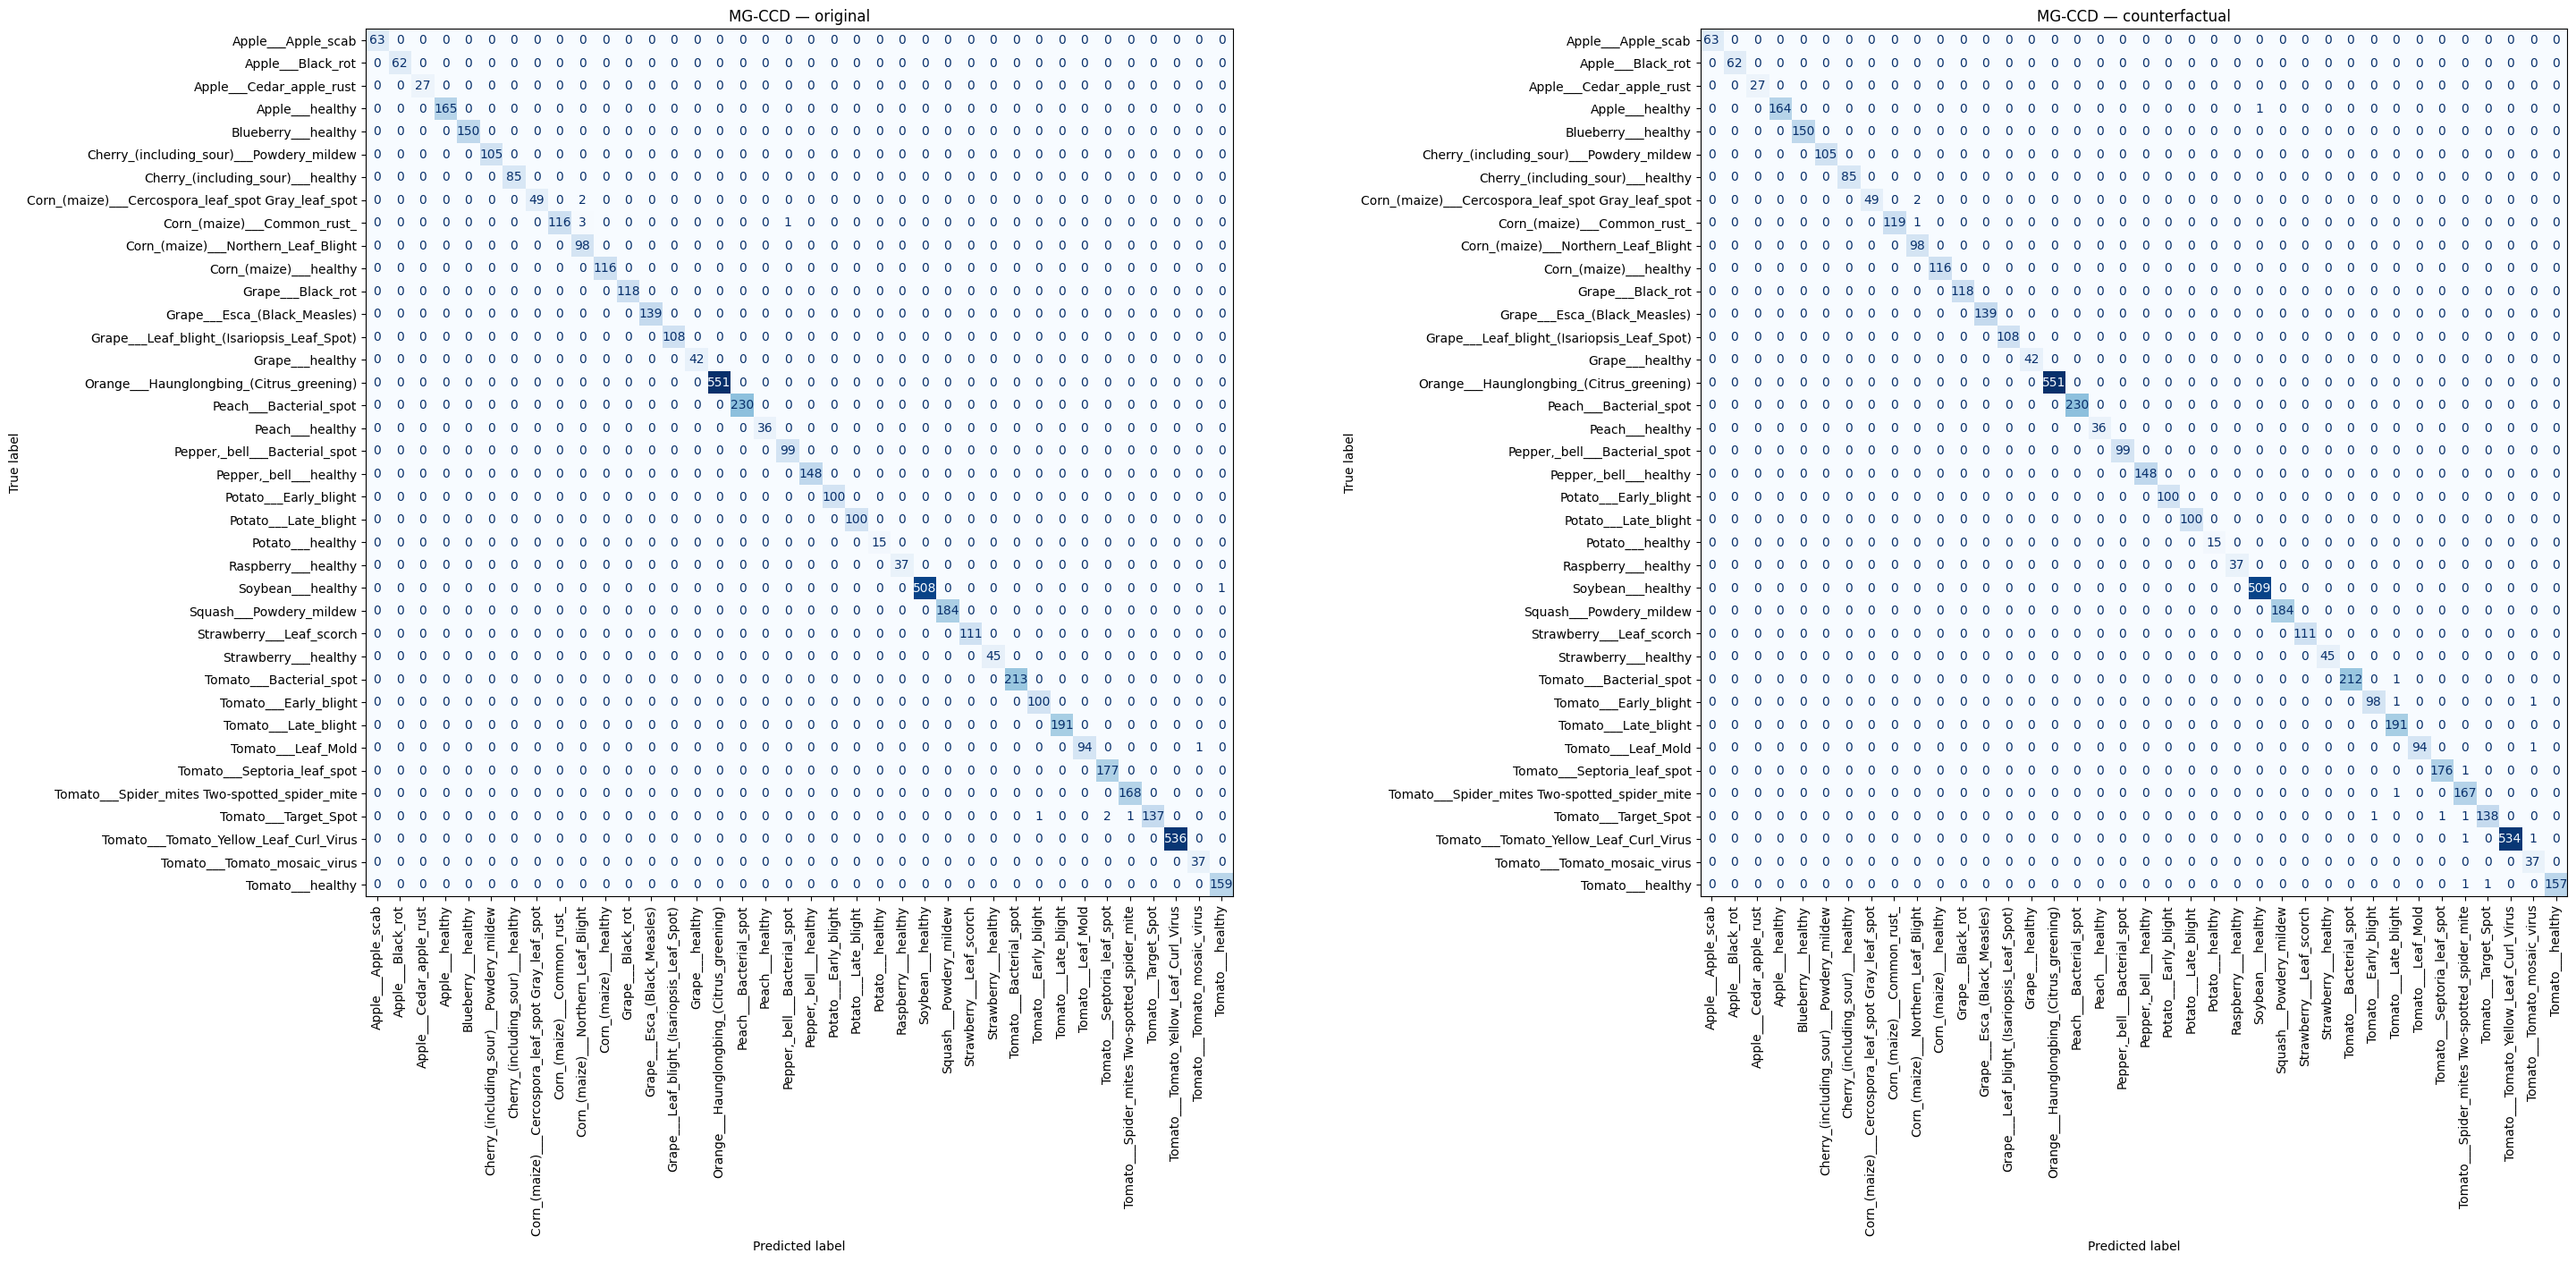

Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/visuals/confusion_original_vs_counterfactual.png


In [22]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        30,
        14
    )
)


for ax, view_name in zip(
    axes,
    [
        "original",
        "counterfactual"
    ]
):

    output = test_outputs[
        view_name
    ]


    cm = confusion_matrix(
        output[
            "y_true"
        ],
        output[
            "y_pred"
        ],
        labels=list(
            range(
                38
            )
        )
    )


    display = (
        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES
        )
    )


    display.plot(
        ax=ax,
        xticks_rotation=90,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )


    ax.set_title(
        f"MG-CCD — {view_name}"
    )


plt.tight_layout()


CONFUSION_PATH = (
    VISUAL_DIR /
    "confusion_original_vs_counterfactual.png"
)


plt.savefig(
    CONFUSION_PATH,
    dpi=220,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    CONFUSION_PATH
)


# STEP 23 — Training Curves

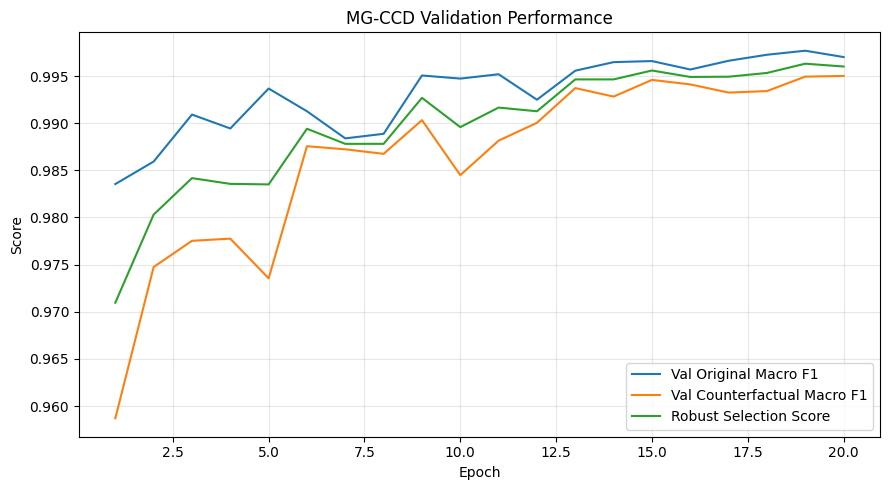

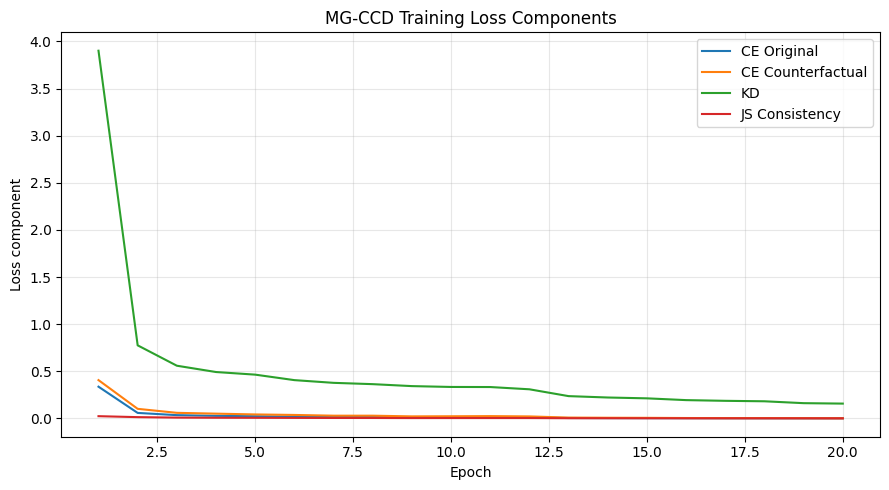

In [23]:
history_df = pd.read_csv(
    HISTORY_PATH
)


plt.figure(
    figsize=(
        9,
        5
    )
)


plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_original_macro_f1"
    ],
    label=
        "Val Original Macro F1"
)


plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_counterfactual_macro_f1"
    ],
    label=
        "Val Counterfactual Macro F1"
)


plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_selection_score"
    ],
    label=
        "Robust Selection Score"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Score"
)

plt.title(
    "MG-CCD Validation Performance"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


VALIDATION_CURVE = (
    VISUAL_DIR /
    "validation_robustness_curve.png"
)


plt.savefig(
    VALIDATION_CURVE,
    dpi=250,
    bbox_inches="tight"
)


plt.show()


plt.figure(
    figsize=(
        9,
        5
    )
)


for column, label in [
    (
        "train_ce_original",
        "CE Original"
    ),
    (
        "train_ce_counterfactual",
        "CE Counterfactual"
    ),
    (
        "train_kd",
        "KD"
    ),
    (
        "train_consistency",
        "JS Consistency"
    )
]:

    plt.plot(
        history_df[
            "epoch"
        ],
        history_df[
            column
        ],
        label=label
    )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss component"
)

plt.title(
    "MG-CCD Training Loss Components"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


LOSS_COMPONENT_FIG = (
    VISUAL_DIR /
    "loss_components.png"
)


plt.savefig(
    LOSS_COMPONENT_FIG,
    dpi=250,
    bbox_inches="tight"
)


plt.show()


# STEP 24 — Original vs Counterfactual Prediction Visuals

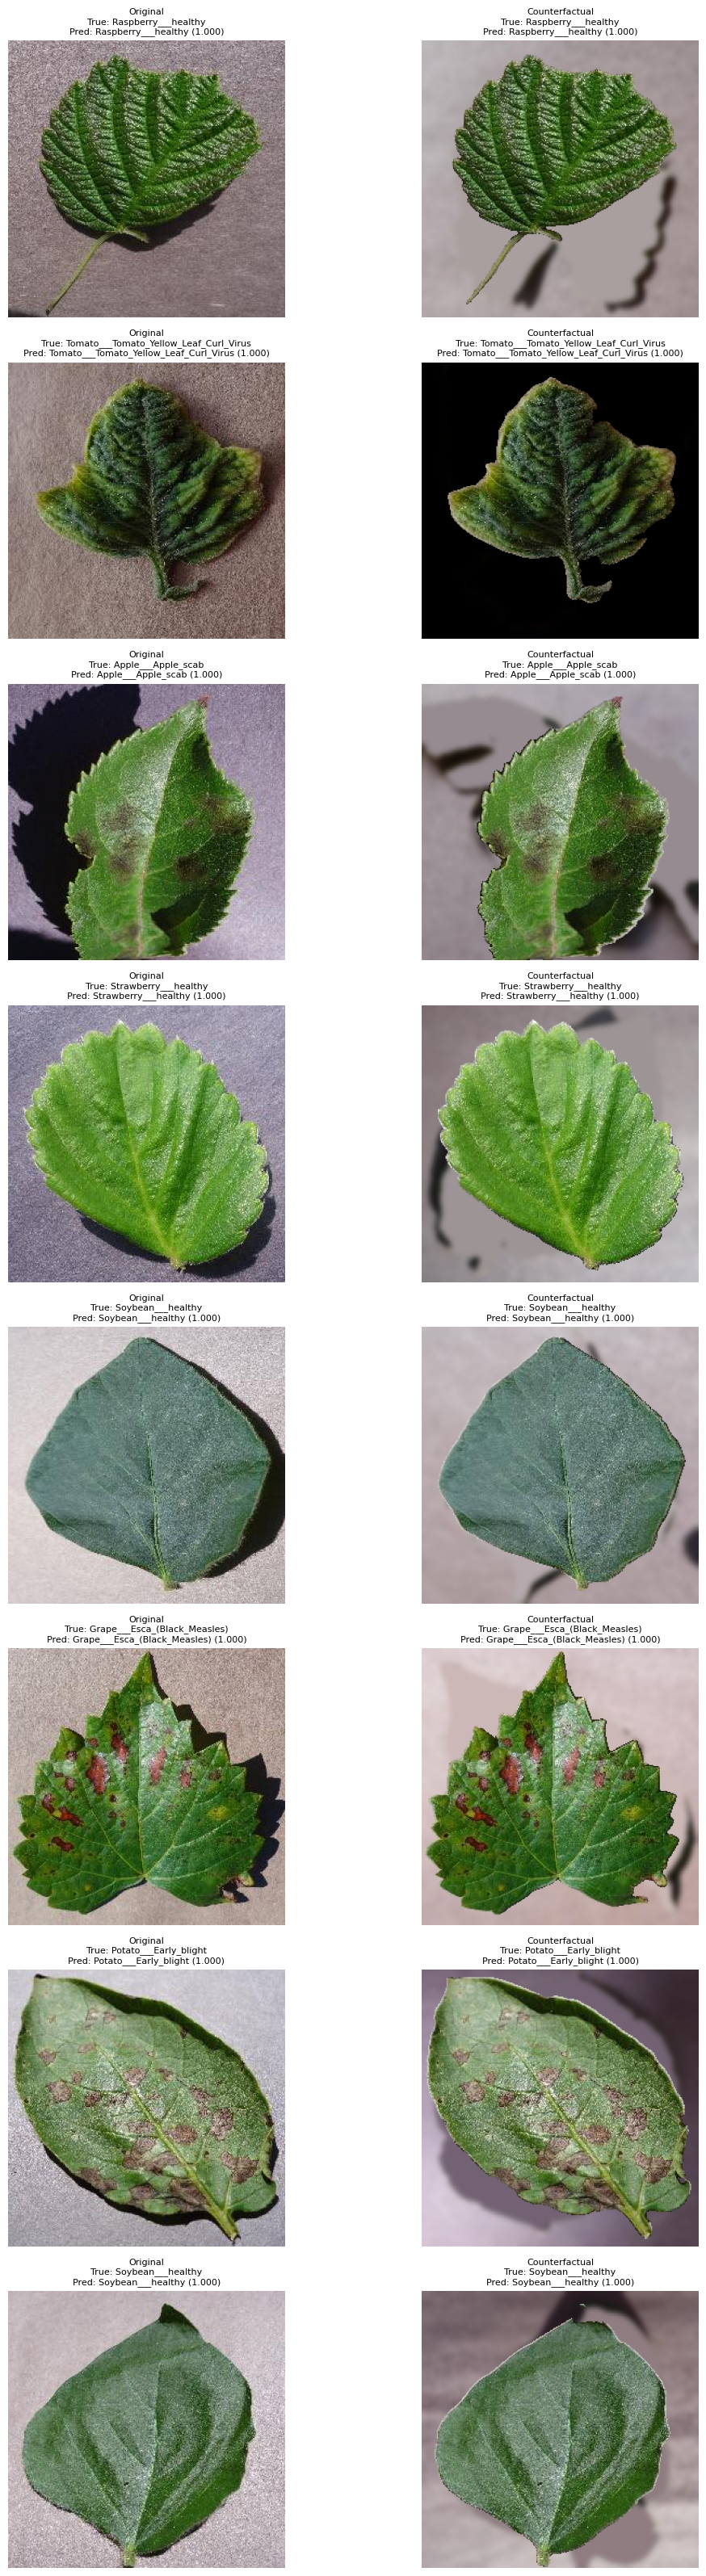

Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/visuals/original_vs_counterfactual_predictions.png


In [24]:
rng = np.random.default_rng(
    SEED
)


indices = rng.choice(
    len(
        test_df
    ),
    size=8,
    replace=False
)


fig, axes = plt.subplots(
    len(
        indices
    ),
    2,
    figsize=(
        12,
        4
        *
        len(
            indices
        )
    )
)


for row_idx, idx in enumerate(
    indices
):

    row = test_df.iloc[
        int(
            idx
        )
    ]


    original = np.array(
        Image.open(
            dataset_root /
            row[
                "color_rel"
            ]
        ).convert(
            "RGB"
        )
    )


    mask = get_mask(
        row[
            "sample_id"
        ]
    )


    partner_id = str(
        row[
            "counterfactual_partner_id"
        ]
    )


    donor_row = row_lookup.loc[
        partner_id
    ]


    donor = np.array(
        Image.open(
            dataset_root /
            donor_row[
                "color_rel"
            ]
        ).convert(
            "RGB"
        )
    )


    donor_mask = get_mask(
        partner_id
    )


    counterfactual = make_counterfactual(
        original,
        mask,
        donor,
        donor_mask
    )


    true_name = CLASS_NAMES[
        int(
            row[
                "class_id"
            ]
        )
    ]


    orig_probs = (
        test_outputs[
            "original"
        ][
            "probabilities"
        ][
            idx
        ]
    )


    cf_probs = (
        test_outputs[
            "counterfactual"
        ][
            "probabilities"
        ][
            idx
        ]
    )


    orig_pred = int(
        orig_probs.argmax()
    )


    cf_pred = int(
        cf_probs.argmax()
    )


    axes[
        row_idx,
        0
    ].imshow(
        original
    )


    axes[
        row_idx,
        0
    ].set_title(
        f"Original\n"
        f"True: {true_name}\n"
        f"Pred: {CLASS_NAMES[orig_pred]} "
        f"({orig_probs[orig_pred]:.3f})",
        fontsize=8
    )


    axes[
        row_idx,
        0
    ].axis(
        "off"
    )


    axes[
        row_idx,
        1
    ].imshow(
        counterfactual
    )


    axes[
        row_idx,
        1
    ].set_title(
        f"Counterfactual\n"
        f"True: {true_name}\n"
        f"Pred: {CLASS_NAMES[cf_pred]} "
        f"({cf_probs[cf_pred]:.3f})",
        fontsize=8
    )


    axes[
        row_idx,
        1
    ].axis(
        "off"
    )


plt.tight_layout()


PAIR_PREDICTION_FIG = (
    VISUAL_DIR /
    "original_vs_counterfactual_predictions.png"
)


plt.savefig(
    PAIR_PREDICTION_FIG,
    dpi=250,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    PAIR_PREDICTION_FIG
)


# STEP 25 — Save Experiment Configuration and Summary

In [ ]:
EXPERIMENT_CONFIG = {
    "model":
        "EfficientNet-B0",

    "method":
        "Mask-Guided Counterfactual Consistency Distillation",

    "abbreviation":
        "MG-CCD",

    "final_inference_input":
        "ordinary RGB image only",

    "train_samples":
        len(
            train_df
        ),

    "validation_samples":
        len(
            val_df
        ),

    "test_samples":
        len(
            test_df
        ),

    "classes":
        38,

    "image_size":
        IMAGE_SIZE,

    "physical_batch_size":
        BATCH_SIZE,

    "gradient_accumulation_steps":
        GRAD_ACCUM_STEPS,

    "effective_optimizer_batch":
        BATCH_SIZE
        *
        GRAD_ACCUM_STEPS,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "max_epochs":
        MAX_EPOCHS,

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "loss_weights":
        {
            "ce_original":
                1.0,

            "ce_counterfactual":
                ALPHA_CF,

            "knowledge_distillation":
                BETA_KD,

            "js_consistency":
                GAMMA_CONSISTENCY
        },

    "kd_temperature":
        KD_TEMPERATURE,

    "teacher":
        "Leaf-Only EfficientNet-B0",

    "teacher_logits_source":
        str(
            TEACHER_LOGITS_PATH
        ),

    "model_selection":
        (
            "harmonic mean of validation "
            "original and counterfactual Macro F1"
        ),

    "seed":
        SEED
}


CONFIG_PATH = (
    RESULTS_DIR /
    "experiment_config.json"
)


with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        EXPERIMENT_CONFIG,
        f,
        indent=4
    )


SUMMARY_PATH = (
    RESULTS_DIR /
    "experiment_summary.json"
)


summary = {
    **EXPERIMENT_CONFIG,

    "best_epoch":
        int(
            best_checkpoint[
                "epoch"
            ]
        ),

    "best_validation_selection_score":
        float(
            best_checkpoint[
                "best_selection_score"
            ]
        ),

    "test_metrics":
        test_results,

    "robustness_summary":
        robustness_summary
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


print(
    "Saved:",
    CONFIG_PATH
)

print(
    "Saved:",
    SUMMARY_PATH
)


# STEP 26 — Verify Final Outputs

In [26]:
required = [
    BEST_MODEL_PATH,
    LAST_CHECKPOINT_PATH,
    HISTORY_PATH,
    MULTIVIEW_JSON,
    MULTIVIEW_CSV,
    ROBUSTNESS_JSON,
    PER_CLASS_PATH,
    CONFUSION_PATH,
    VALIDATION_CURVE,
    LOSS_COMPONENT_FIG,
    PAIR_PREDICTION_FIG,
    CONFIG_PATH,
    SUMMARY_PATH,
    COMPLETE_MARKER
]


all_ok = True


for path in required:

    exists = Path(
        path
    ).exists()

    print(
        "✅" if exists else "❌",
        path
    )

    all_ok = (
        all_ok
        and
        exists
    )


assert all_ok


print(
    "\n✅ MG-CCD EXPERIMENT COMPLETE AND RECOVERABLE."
)


✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/checkpoints/best_model.pth
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/checkpoints/last_checkpoint.pth
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/results/training_history.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/results/multiview_test_metrics.json
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/results/multiview_test_metrics.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/results/robustness_summary.json
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/results/per_class_multiview_report.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/visuals/confusion_original_vs_counterfactual.png
✅ /content/drive/MyDrive/

# What to send back after completion

Please send the final outputs for:

```text
Best epoch
Best validation robustness selection score

Original:
- Accuracy
- Balanced Accuracy
- Macro F1

Leaf-only:
- Accuracy
- Balanced Accuracy
- Macro F1

Background-only:
- Accuracy
- Balanced Accuracy
- Macro F1

Counterfactual:
- Accuracy
- Balanced Accuracy
- Macro F1

Robustness summary:
- Original → Counterfactual Macro F1 drop
- Original/Counterfactual prediction agreement
- Both-correct rate
```

Also send the final notebook itself.

After this experiment is verified, the final notebook will be:

```text
05_PlantVillage_Classification_Robustness_and_Model_Comparison.ipynb
```
